# Superconductor Study
- Analyze large & complex scientific data from Superconductor company
- Use the structured dataset to predict the existence of new particle
- Using Neural Network with Early stopping
## EDA

In [29]:
import tensorflow as tf
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
from sklearn.preprocessing import StandardScaler,MinMaxScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Dropout
from tensorflow.keras.callbacks import EarlyStopping


In [3]:
df = pd.read_csv("all_train.csv.gz")

In [4]:
df.shape

(7000000, 29)

In [5]:
df.head()

,# label,f0,f1,f2,f3,f4,f5,f6,f7,f8,...,f18,f19,f20,f21,f22,f23,f24,f25,f26,mass
0,1.0,-0.346368,0.416306,0.999236,0.475342,0.427493,-0.005984,1.989833,0.344530,1.566297,...,4.105282,0.267826,0.378718,1.743123,3.406367,4.350537,-0.352571,1.130032,2.227706,1000.0
1,1.0,1.708236,-0.319394,-1.241873,-0.887231,-0.871906,-0.005984,-0.001047,-1.038225,0.655748,...,-1.178141,-0.877361,-1.483769,-0.573682,-1.693781,-0.545062,-0.299118,-0.662942,-0.193019,750.0
2,0.0,-0.360693,1.794174,0.264738,-0.472273,-0.292344,-1.054221,-1.150495,1.423404,1.270098,...,-1.199511,0.539020,-1.590629,-0.573682,-0.543636,-0.937456,-0.300344,-0.523262,-1.506304,750.0
3,1.0,-0.377914,-0.103932,-0.649434,-2.125015,-1.643797,-0.005984,1.011112,-1.040340,-0.541991,...,0.463763,-0.006583,1.089122,-0.573682,-0.276348,-0.409272,-0.349926,-0.307123,0.529698,1250.0
4,0.0,-0.067436,-0.636762,-0.620166,-0.062551,1.588715,-0.005984,-0.595304,-1.238987,0.336844,...,-0.552837,-1.418494,-0.562982,1.743123,0.881802,0.002516,1.560950,-0.150760,-1.023889,750.0


- The entire data has 70 million rows and 29 columns
- The label is the first column with binary data of 0 and 1 with 1 stands for new particle found
- Mass is the only feature having very high values, the other 27 features from f0 to f26 have standardized values


### Check for missing value

In [18]:
missing = pd.DataFrame(df.isnull().sum(), columns=['Missing'])
missing['Percentage'] = (missing['Missing'] / len(df)) * 100
missing = missing.sort_values(by='Percentage', ascending=True)

In [19]:
missing.sum()

Missing       0.0
Percentage    0.0
dtype: float64

### Distribution of label value

In [31]:
par_counts = df['# label'].value_counts().reset_index()


In [32]:
par_counts

,# label,count
0,1.0,3500879
1,0.0,3499121


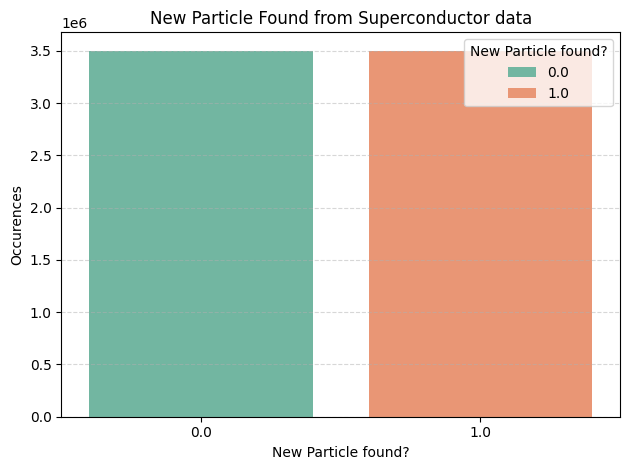

In [30]:
# Convert value_counts to DataFrame
par_counts = df['# label'].value_counts().reset_index()
par_counts.columns = ['New Particle found?', 'count']

# Plot using seaborn
sns.barplot(data=par_counts, x='New Particle found?', y='count', hue='New Particle found?', palette='Set2')
plt.title('New Particle Found from Superconductor data')
plt.xlabel('New Particle found?')
plt.ylabel('Occurences')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

- Equality distribution in label dataset
- We split the input data into X and y and training/testing
- As the purpose of this study is to apply neural network on this huge dataset, we do not need to reduce the dimension of the input data.


In [6]:
X = df.iloc[:,1:]
y = df.iloc[:,0]

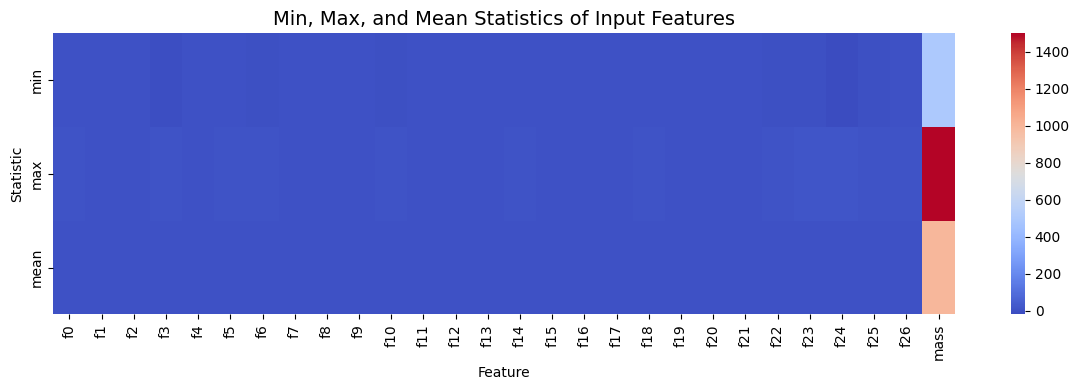

In [36]:
# Filter to just min, max, and mean
desc = X.describe().loc[["min", "max", "mean"]]

# Plot
plt.figure(figsize=(12, 4))
sns.heatmap(desc, annot=False, fmt=".2f", cmap="coolwarm", cbar=True)

# Titles and labels
plt.title("Min, Max, and Mean Statistics of Input Features", fontsize=14)
plt.ylabel("Statistic")
plt.xlabel("Feature")

plt.tight_layout()
plt.show()


- The quick statistic analysis with min, max and mean value for all 28 input features show that the first 27 features have the same scale while the mass does not
- We will have to apply standard scaler to this data

## Modeling with Tensorflow

In [7]:
X_train,X_test,y_train,y_test = train_test_split(X,y,train_size=0.8,random_state=123)

In [8]:
# Apply StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Create NN network with hidden layers

In [9]:
model = Sequential()
model.add(Dense(units=512,activation="relu",input_shape=(28,)))
model.add(Dense(units=256,activation="relu"))
model.add(Dense(units=1,activation="sigmoid"))

2025-07-20 22:52:25.150209: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-07-20 22:52:25.753605: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1532] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 30977 MB memory:  -> device: 0, name: Tesla V100-SXM2-32GB, pci bus id: 0000:15:00.0, compute capability: 7.0


In [10]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 512)               14848     
                                                                 
 dense_1 (Dense)             (None, 256)               131328    
                                                                 
 dense_2 (Dense)             (None, 1)                 257       
                                                                 
Total params: 146,433
Trainable params: 146,433
Non-trainable params: 0
_________________________________________________________________


In [11]:
model.compile(optimizer="adam",loss="binary_crossentropy",metrics=['accuracy'])

In [14]:
# Set up EarlyStopping
early_stop = EarlyStopping(
    monitor='val_loss',      # Monitor validation loss
    patience=5,              # Number of epochs with no improvement after which training stops
    restore_best_weights=True  # Restore model weights from the epoch with the best value of the monitored quantity
)

In [15]:
%%time
history = model.fit(X_train_scaled,y_train,
                    epochs=100,
                    batch_size=1000,
                    verbose=1,
                    validation_data=(X_test_scaled,y_test),
                    callbacks=[early_stop])

Epoch 1/100
5600/5600 [==============================] - 9s 2ms/step - loss: 0.2605 - accuracy: 0.8830 - val_loss: 0.2613 - val_accuracy: 0.8825
Epoch 2/100
5600/5600 [==============================] - 8s 2ms/step - loss: 0.2592 - accuracy: 0.8836 - val_loss: 0.2605 - val_accuracy: 0.8832
Epoch 3/100
5600/5600 [==============================] - 8s 1ms/step - loss: 0.2581 - accuracy: 0.8842 - val_loss: 0.2600 - val_accuracy: 0.8833
Epoch 4/100
5600/5600 [==============================] - 8s 2ms/step - loss: 0.2572 - accuracy: 0.8847 - val_loss: 0.2614 - val_accuracy: 0.8828
Epoch 5/100
5600/5600 [==============================] - 8s 2ms/step - loss: 0.2564 - accuracy: 0.8851 - val_loss: 0.2588 - val_accuracy: 0.8841
Epoch 6/100
5600/5600 [==============================] - 8s 2ms/step - loss: 0.2555 - accuracy: 0.8855 - val_loss: 0.2595 - val_accuracy: 0.8836
Epoch 7/100
5600/5600 [==============================] - 8s 2ms/step - loss: 0.2548 - accuracy: 0.8860 - val_loss: 0.2589 - val_ac

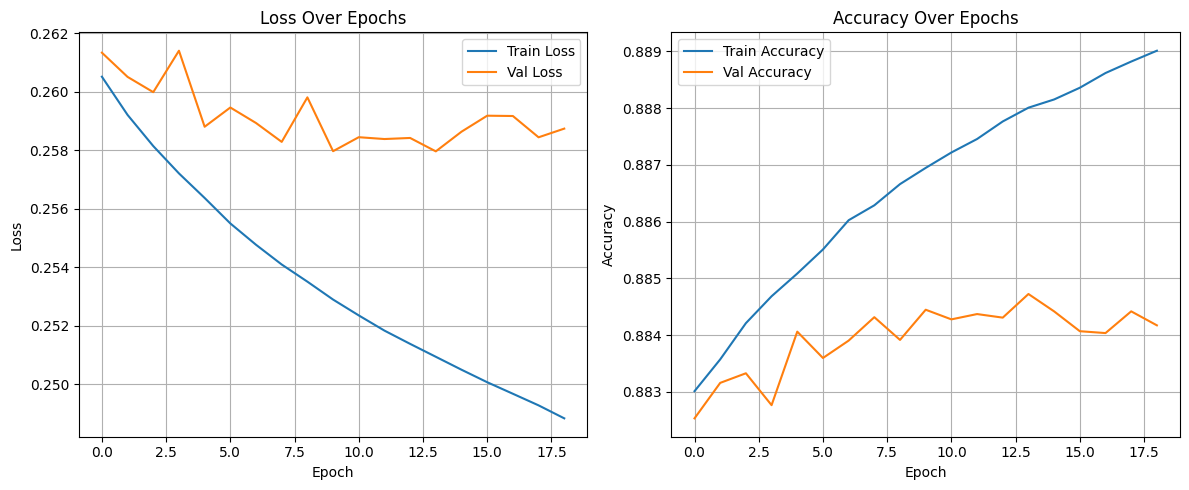

In [38]:
# Extract training history
hist = history.history

# Plot Loss
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(hist['loss'], label='Train Loss')
plt.plot(hist['val_loss'], label='Val Loss')
plt.title('Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(hist['accuracy'], label='Train Accuracy')
plt.plot(hist['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()
